# Machine Learning Model

## Data Context

### Imports

In [1]:
import pandas as pd
import pickle

%run "../utils/notebook_utils.py"
%run "../utils/feature_categories.py"

### Dataset Info

In [2]:
TRAINING_DATA = "../data/Training.parquet"
TARGET = "status"
full_data_frame = pd.read_parquet(TRAINING_DATA, engine='pyarrow')
full_data_frame

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,https://www.todayshomeowner.com/how-to-make-ho...,82,23,0,2,7,0,0,0,0,...,1,1,0,240,8892,67860,0,1,4,legitimate
1,http://thapthan.ac.th/information/confirmation...,93,14,1,2,0,0,0,0,0,...,1,0,1,0,2996,4189860,0,1,2,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,121,21,1,3,0,0,0,0,0,...,1,1,0,30,2527,346022,0,1,3,phishing
3,https://www.bedslide.com,24,16,0,2,0,0,0,0,0,...,0,0,0,139,7531,1059151,0,0,4,legitimate
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,73,24,0,3,1,0,0,0,0,...,0,0,0,3002,7590,635,0,1,5,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7653,https://snip.ly/www.netflix.com-signIn-account...,63,7,0,3,2,0,1,0,0,...,1,0,0,0,2344,13667,0,1,6,phishing
7654,http://webchat.freenode.net/,28,20,0,2,0,0,0,0,0,...,1,0,0,1813,6588,140438,0,0,6,legitimate
7655,http://mr-statucki.com/wp-content/uploads/2009...,67,15,0,2,2,0,0,0,0,...,1,1,0,100,5014,0,0,1,0,phishing
7656,https://www.computerhope.com/jargon/c/cdrom.htm,47,20,0,3,0,0,0,0,0,...,1,1,0,3482,8045,2580,0,0,6,legitimate


### Dataset Statistics

In [3]:
# full_data_frame.describe()
full_data_frame.columns

Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 

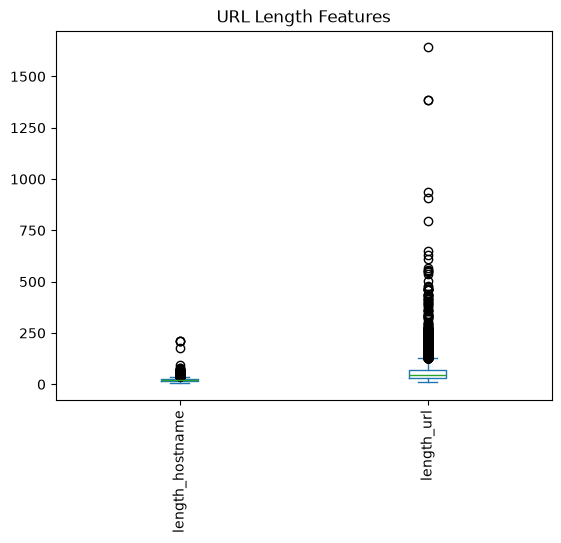

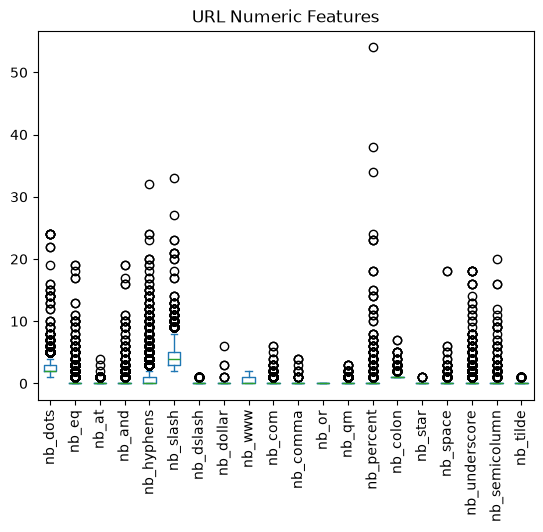

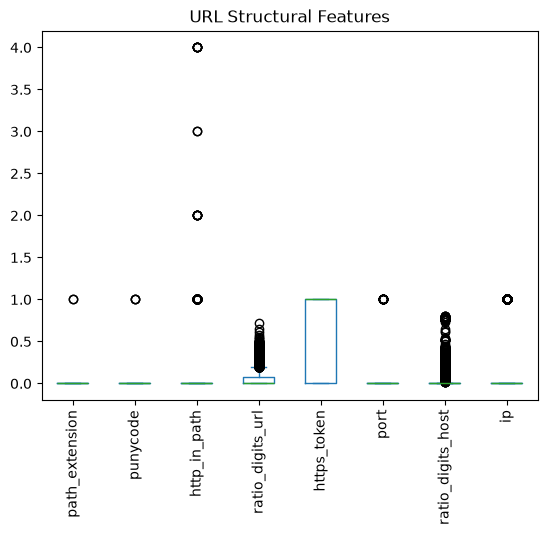

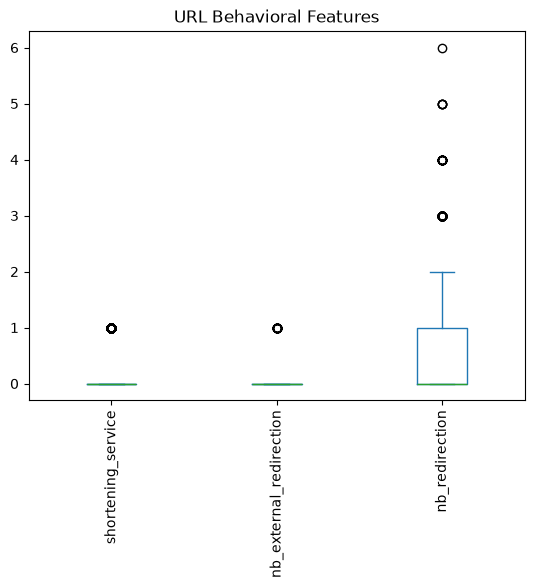

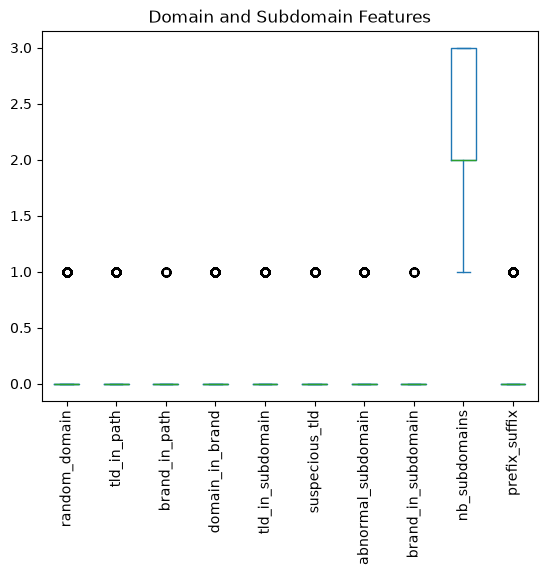

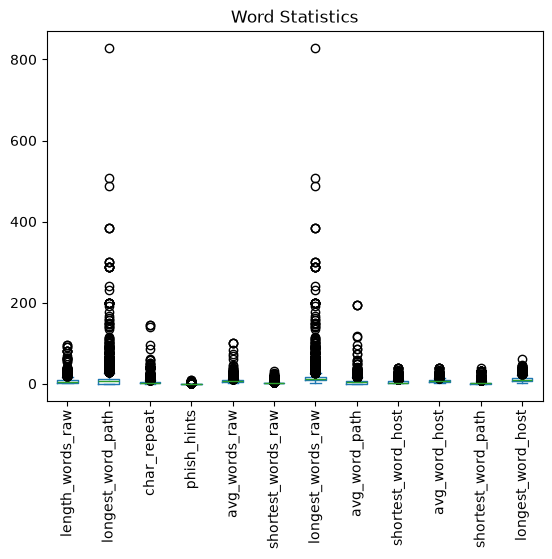

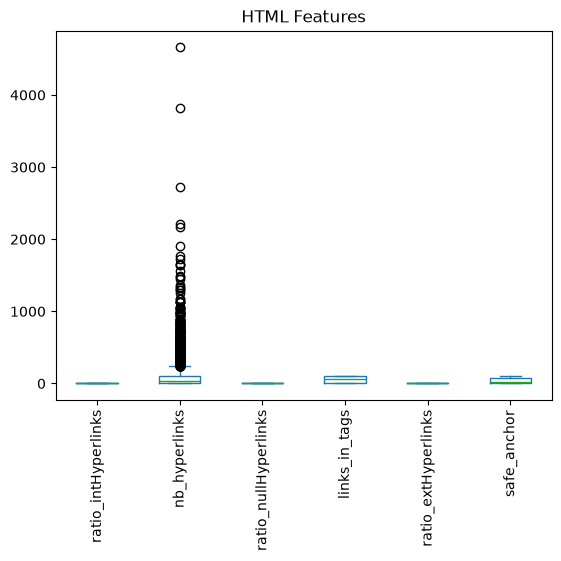

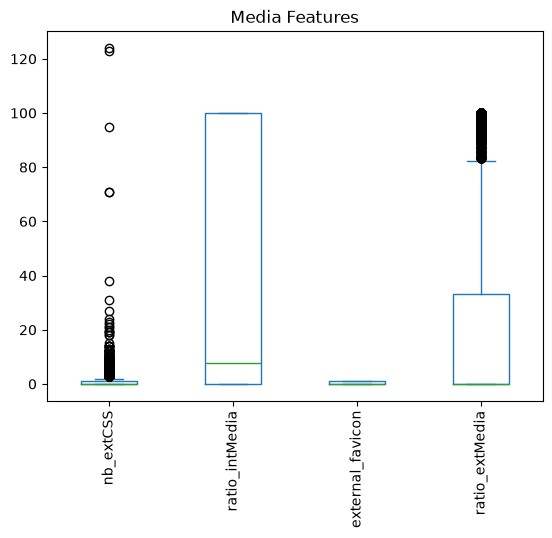

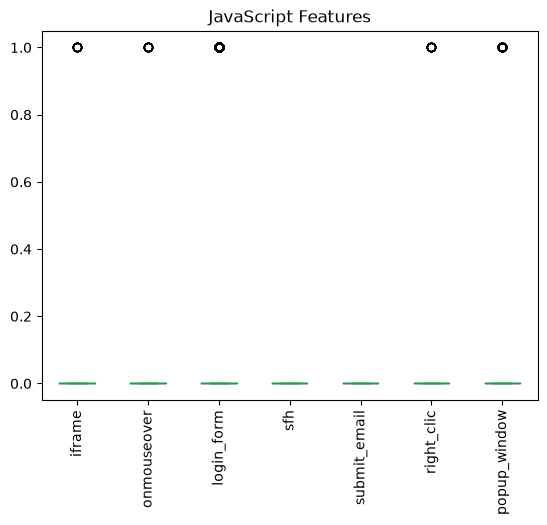

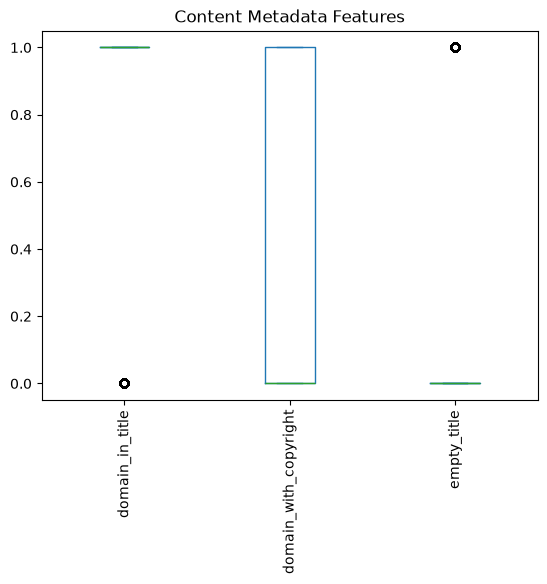

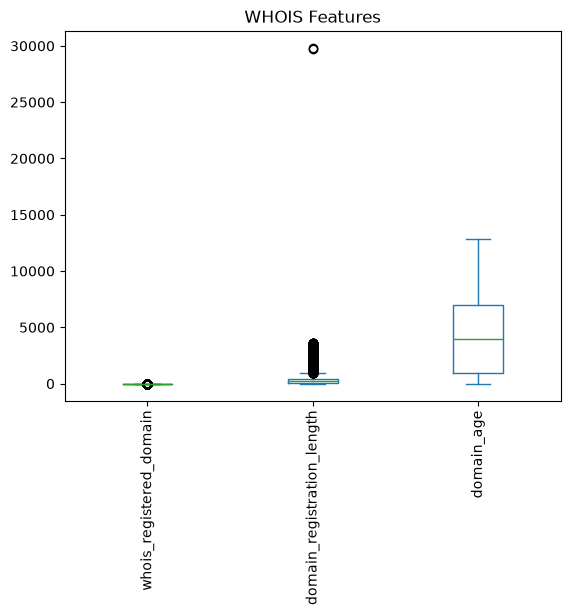

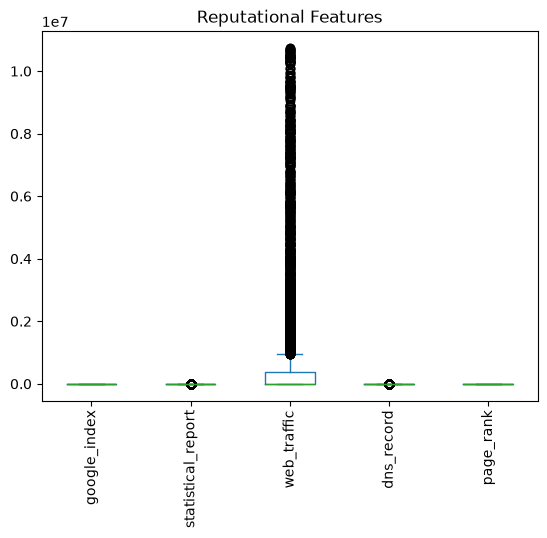

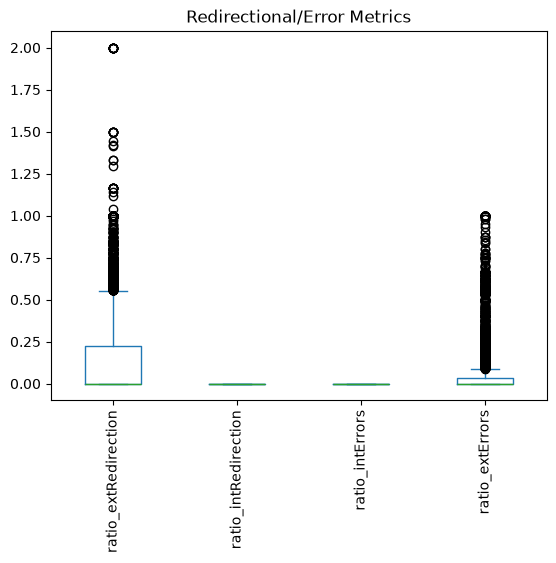

In [4]:
for title, columns in FEATURE_CATEGORIES.items():
    data_frame = generate_sub_data_frame(columns, add_status=False)
    frame_box_plot(
        data_frame, title
    )

### Boolean Attributes
These are attributes that indicate whether a specific feature is present or not present.

In [5]:
BOOLEAN_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 2)]. columns
)

len(BOOLEAN_ATTRIBUTES)

32

### Non-Boolean Attributes
These attributes are much more diverse and complex in comparison to boolean attributes. This includes numerical values asides from 0 and 1 and URLs themselves.

In [6]:
NON_BOOL_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() > 2)].columns
)

len(NON_BOOL_ATTRIBUTES)

51

## Removing Redundant Attributes

### Constant Features
These are features whose values are all the same across every URL and thereby serve no purpose in distinguishing between a phishing link and a legitimate link.

In [7]:
REDUNDANT_FEATURES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 1)].columns
)

REDUNDANT_FEATURES

{'nb_or',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'sfh',
 'submit_email'}

Below we remove these features to address the curse of dimensionality.

In [8]:
RELEVANT_FEATURES = [
    attr for attr in full_data_frame.columns
    if attr not in REDUNDANT_FEATURES
]

### Highly Correlated Features
These features can be identified visually via a correlation matrix.

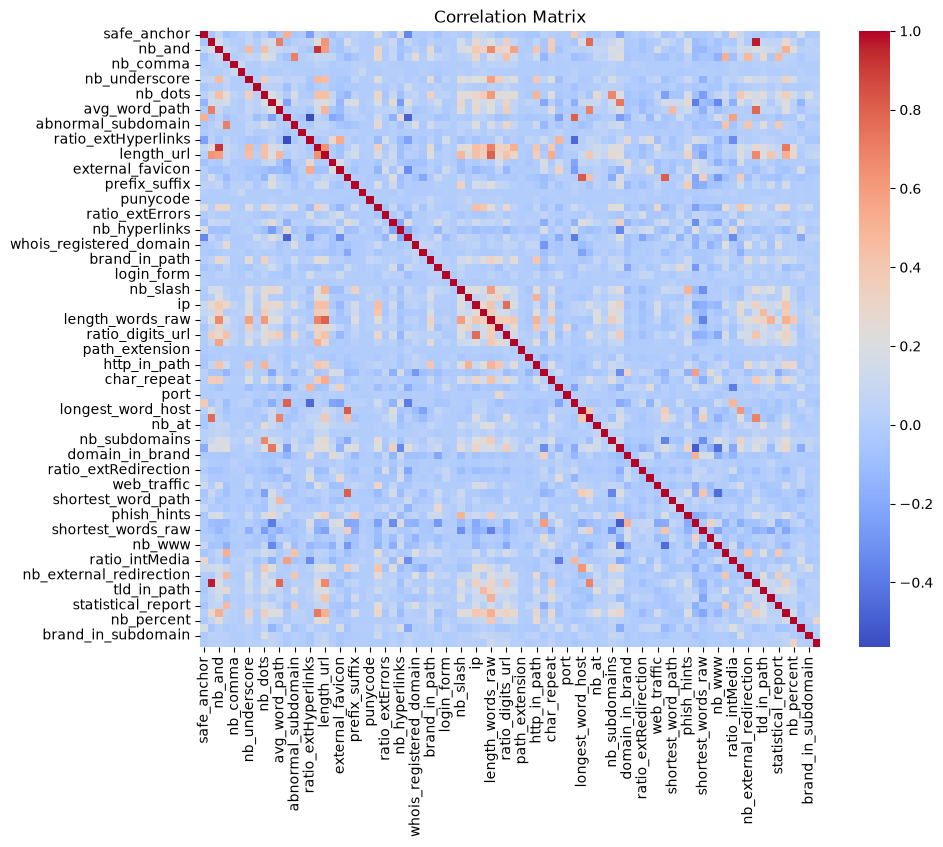

In [9]:
cleaned_data_frame_1 = generate_sub_data_frame(
    set(RELEVANT_FEATURES)
)

frame_correlation_matrix(cleaned_data_frame_1, annotate=False)

#### Top 10 Highest Correlation Pairings

In [10]:
get_top_correlation_pairs(cleaned_data_frame_1, 10)

longest_word_path   longest_words_raw      0.969159
nb_eq               nb_and                 0.920944
avg_word_host       longest_word_host      0.820717
shortest_word_host  avg_word_host          0.809354
links_in_tags       ratio_intHyperlinks    0.800605
length_words_raw    length_url             0.799836
longest_word_path   avg_word_path          0.783384
longest_words_raw   avg_words_raw          0.775309
ip                  ratio_digits_url       0.764657
status              google_index           0.734620
dtype: float64

#### Highly Correlated Pairs
Each pair represents a highly-correlated intersecting point in the correlation matrix.

In [11]:
get_highly_correlated_pairs(cleaned_data_frame_1)

{('avg_word_host', 'longest_word_host'),
 ('length_words_raw', 'length_url'),
 ('links_in_tags', 'ratio_intHyperlinks'),
 ('longest_word_path', 'longest_words_raw'),
 ('nb_eq', 'nb_and'),
 ('shortest_word_host', 'avg_word_host')}

#### Redundant Feature Inference from Correlation
From each of the highly-correlated pairing of features shown above, we can infer the feature that is most redundant based on each feature's correlation value to determining the *status* of a URL.

In [12]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

get_redundant_correlated_features(cleaned_data_frame_1)

{'avg_word_host',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and'}

In [13]:
REDUNDANT_FEATURES.update(
    get_low_target_correlation_features(cleaned_data_frame_1)
)

get_low_target_correlation_features(cleaned_data_frame_1)

{'iframe', 'nb_space', 'onmouseover', 'path_extension', 'right_clic'}

In [14]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

with open('../utils/redundant_features.pkl', 'wb') as file:
    pickle.dump(REDUNDANT_FEATURES, file)

REDUNDANT_FEATURES

{'avg_word_host',
 'iframe',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and',
 'nb_or',
 'nb_space',
 'onmouseover',
 'path_extension',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'right_clic',
 'sfh',
 'submit_email'}

In [15]:
RELEVANT_FEATURES = [
    attr for attr in cleaned_data_frame_1.columns
    if attr not in REDUNDANT_FEATURES
]

len(RELEVANT_FEATURES)

72

## Clean Dataset Context

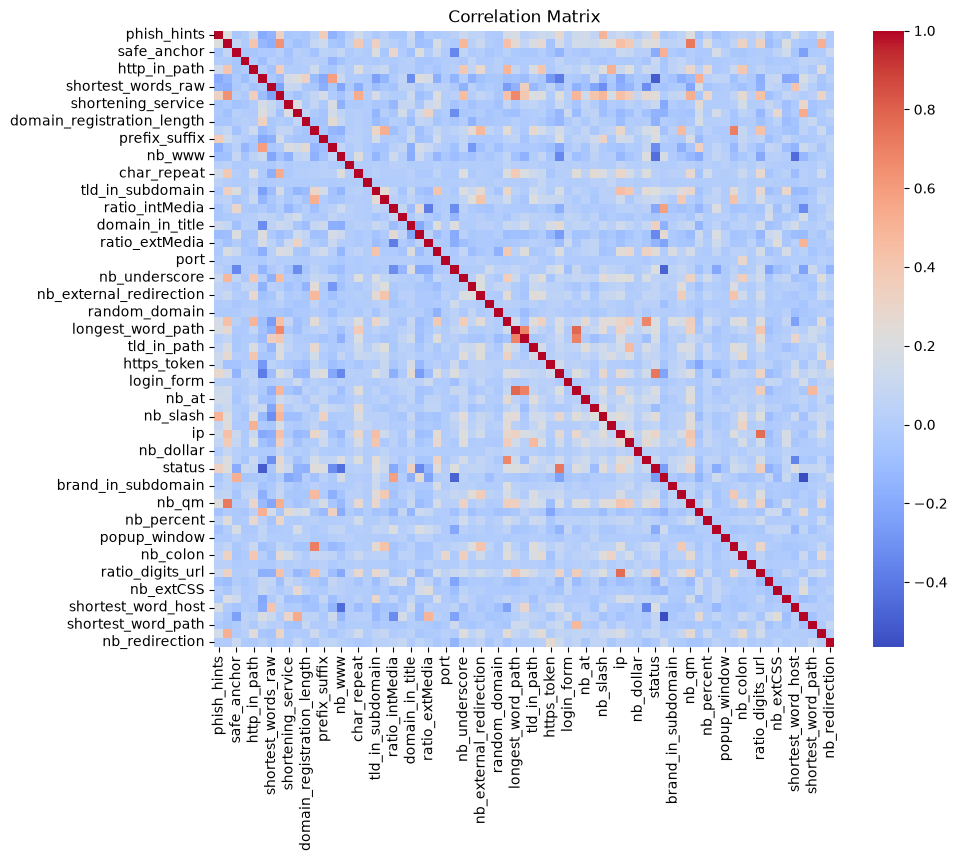

In [16]:
cleaned_data_frame_2 = generate_sub_data_frame(
    set(RELEVANT_FEATURES)
)

frame_correlation_matrix(cleaned_data_frame_2, annotate=False)

In [17]:
get_top_correlation_pairs(cleaned_data_frame_2, 10)

longest_word_path  avg_word_path         0.783384
ratio_digits_url   ip                    0.764657
google_index       status                0.734620
nb_eq              nb_qm                 0.725301
ratio_digits_host  abnormal_subdomain    0.704427
avg_words_raw      avg_word_path         0.699656
                   longest_word_path     0.689232
nb_subdomains      nb_dots               0.678439
longest_word_path  length_url            0.675539
nb_eq              length_url            0.637347
dtype: float64

In [18]:
get_correlation_to_target(
    set(cleaned_data_frame_2.columns)
)

status                 1.000000
google_index           0.734620
ratio_digits_url       0.354270
domain_in_title        0.335234
phish_hints            0.331244
                         ...   
ratio_intHyperlinks   -0.256211
domain_age            -0.323937
nb_hyperlinks         -0.342196
nb_www                -0.440457
page_rank             -0.503594
Name: status, Length: 71, dtype: float64